In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# STEP 2: Import required libraries
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

In [ ]:
# STEP 3: Load and preprocess image paths from Google Drive
image_folder = '/content/drive/MyDrive/dataset'  
image_paths = glob.glob(os.path.join(image_folder, '**', '*.png'), recursive=True)
print(f"Found {len(image_paths)} images")


Found 68 images


In [ ]:
# STEP 4: Load VGG16 model for feature extraction
base_model = VGG16(weights='imagenet')
model = Model(inputs=base_model.input, outputs=base_model.get_layer('fc1').output)

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = model.predict(img_array, verbose=0)
    return features.flatten()


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# STEP 5: Extract features from each image
features = []
valid_paths = []

for path in image_paths:
    try:
        feat = extract_features(path)
        features.append(feat)
        valid_paths.append(path)
    except Exception as e:
        print(f"Error with {path}: {e}")

features = np.array(features)
print(f"Extracted features from {len(features)} images.")


Extracted features from 68 images.


In [ ]:
# STEP 6: Cluster using KMeans
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(features)


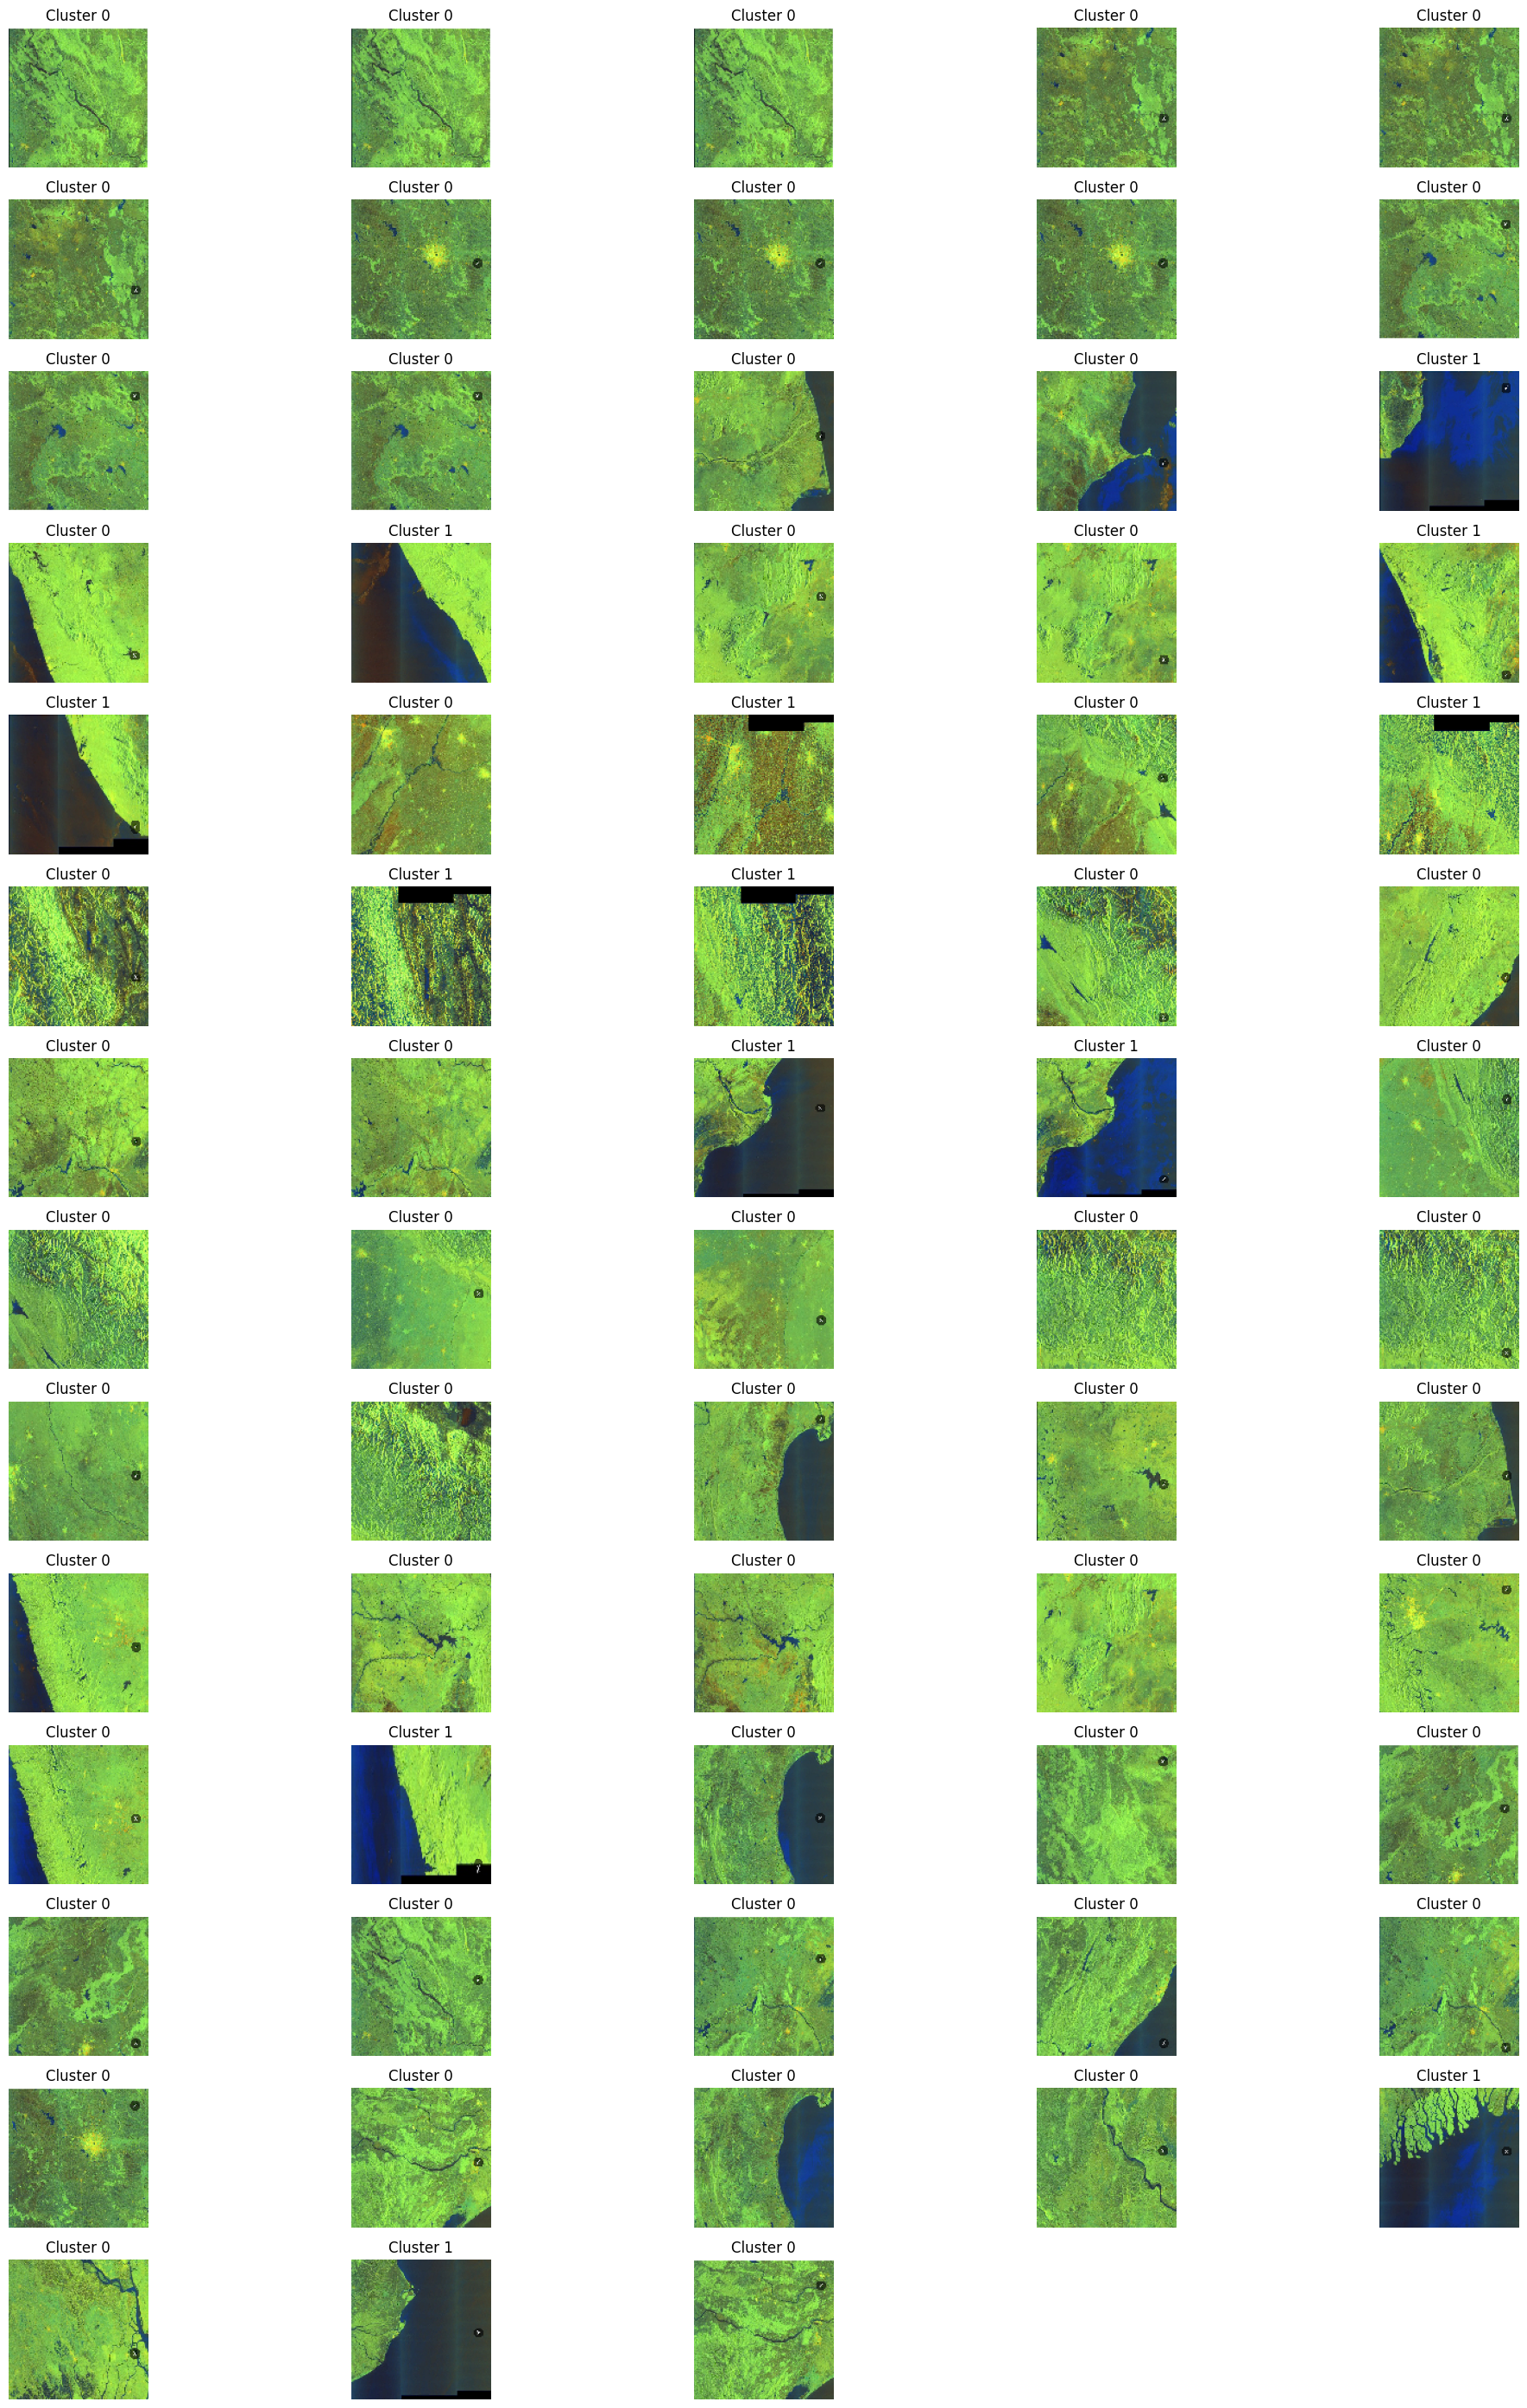

In [ ]:
# STEP 7: Visualize cluster assignment
# Calculate the number of rows needed to accommodate all images
num_rows = int(len(valid_paths) / 5) + 1

plt.figure(figsize=(20, num_rows * 2))  # Adjust figure height as needed

for i, path in enumerate(valid_paths):
    img = image.load_img(path, target_size=(128, 128))
    plt.subplot(num_rows, 5, i+1) # Updated to use num_rows
    plt.imshow(img)
    plt.title(f"Cluster {clusters[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# STEP 8: Organize images into folders by cluster (for CNN training)
import shutil

output_dir = 'C:\Users\nithi\OneDrive\Desktop\CSE\flood detection\model'
os.makedirs(output_dir, exist_ok=True)
for i in range(2):
    os.makedirs(os.path.join(output_dir, f'cluster_{i}'), exist_ok=True)

for path, label in zip(valid_paths, clusters):
    filename = os.path.basename(path)
    dest_path = os.path.join(output_dir, f'cluster_{label}', filename)
    shutil.copy(path, dest_path)


In [ ]:
# STEP 9: Setup ImageDataGenerators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    output_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    output_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)


Found 67 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
# STEP 10: Define CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 11: Train the CNN model
history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5913 - loss: 1.5003 - val_accuracy: 0.2500 - val_loss: 0.7465
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.6093 - loss: 0.7893 - val_accuracy: 0.7500 - val_loss: 0.5863
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 416ms/step - accuracy: 0.7842 - loss: 0.5532 - val_accuracy: 0.7500 - val_loss: 0.5653
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 0.7804 - loss: 0.5416 - val_accuracy: 0.7500 - val_loss: 0.5411
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - accuracy: 0.8944 - loss: 0.4100 - val_accuracy: 0.7500 - val_loss: 0.5990
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step - accuracy: 0.8859 - loss: 0.3686 - val_accuracy: 0.7500 - val_loss: 0.6221
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.8287 - loss: 0.4368 - val_accuracy: 0.7500 - val_loss: 0.5738
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.8193 - loss: 0.4241 - val_accuracy: 0.7500 - val_loss: 0

Epoch-wise Accuracy:
Epoch 1: Train Accuracy = 0.6567, Validation Accuracy = 0.2500
Epoch 2: Train Accuracy = 0.6716, Validation Accuracy = 0.7500
Epoch 3: Train Accuracy = 0.7910, Validation Accuracy = 0.7500
Epoch 4: Train Accuracy = 0.8209, Validation Accuracy = 0.7500
Epoch 5: Train Accuracy = 0.8209, Validation Accuracy = 0.7500
Epoch 6: Train Accuracy = 0.8507, Validation Accuracy = 0.7500
Epoch 7: Train Accuracy = 0.8209, Validation Accuracy = 0.7500
Epoch 8: Train Accuracy = 0.8060, Validation Accuracy = 0.7500
Epoch 9: Train Accuracy = 0.8358, Validation Accuracy = 0.7500
Epoch 10: Train Accuracy = 0.8358, Validation Accuracy = 0.7500


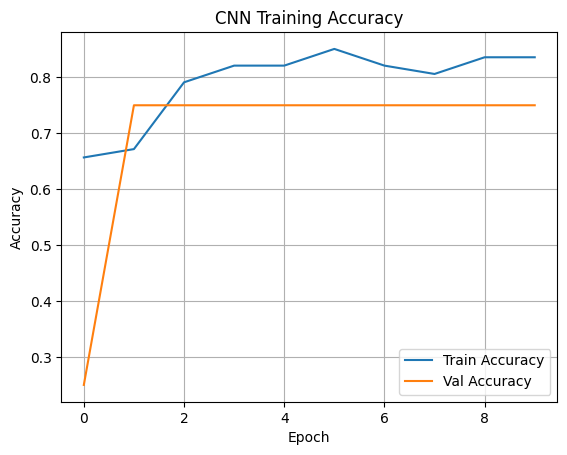

In [ ]:
# STEP 12: Plot training results and show numeric accuracy values
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# Print accuracy values per epoch
print("Epoch-wise Accuracy:")
for i, (train, val) in enumerate(zip(train_acc, val_acc), 1):
    print(f"Epoch {i}: Train Accuracy = {train:.4f}, Validation Accuracy = {val:.4f}")

# Plotting
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()


In [ ]:
# STEP 13: Save the trained model
cnn_model.save('/content/drive/MyDrive/flood_cnn_model.h5')

prediction on new images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step
Raw Prediction Score: 0.9530319571495056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Raw Prediction Score: 0.6118230819702148
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw Prediction Score: 0.9999812841415405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Raw Prediction Score: 0.985209047794342
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Raw Prediction Score: 0.935306191444397
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Raw Prediction Score: 0.04137188568711281
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Raw Prediction Score: 0.057838015258312225
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw Prediction Score: 0.04530222713947296
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Raw Prediction Score: 0.02705509029328823
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Raw Prediction Score: 0.03815111517906189
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Raw Prediction Score: 0.05178624019026756
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raw Prediction Score: 0.03284183144569397
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Raw Pre

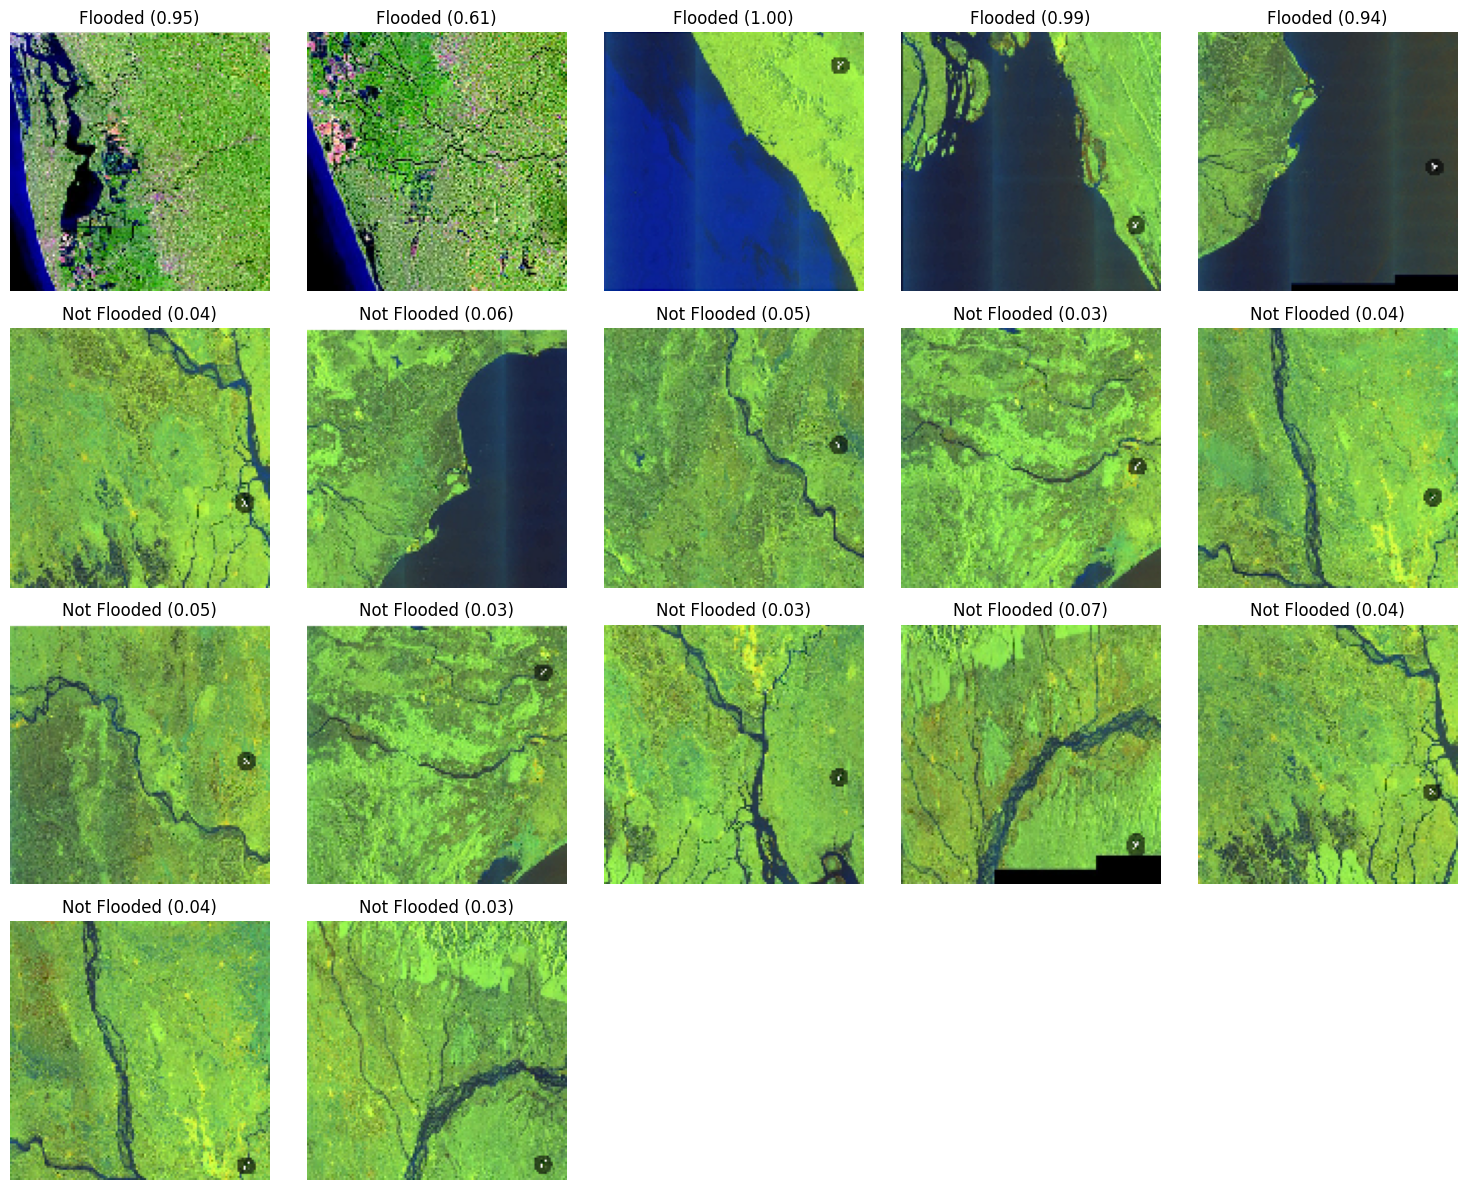

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import os
import matplotlib.pyplot as plt

# Load the trained model
model_path = '/content/drive/MyDrive/flood_cnn_model.h5'
model = load_model(model_path)

# Path to new test images
test_folder = '/content/drive/MyDrive/testdata'   
test_paths = [os.path.join(test_folder, fname) for fname in os.listdir(test_folder) if fname.endswith('.png')]

# Predict and show results
plt.figure(figsize=(15, 12))  # Increased height for more rows
for i, img_path in enumerate(test_paths):
    img = image.load_img(img_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]
    print(f"Raw Prediction Score: {prediction}")
    label = "Flooded" if prediction > 0.45 else "Not Flooded"

    plt.subplot(4, 5, i + 1)  # Changed to 4 rows × 5 columns
    plt.imshow(img)
    plt.title(f"{label} ({prediction:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()
